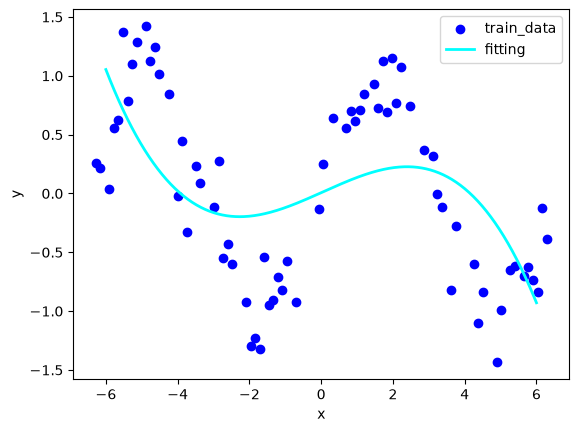

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def convert(x):
    new_x=[]
    for i in x:
        new_x.append([1,i,i**2,i**3])
    return np.array(new_x)

def read_csv(path):
    with open(path,'r') as file:
        headers=file.readline().strip().split(',')

    x_cols=[i for i in range(len(headers)) if headers[i]=='x']
    y_cols=[i for i in range(len(headers)) if headers[i]=='y']

    x=np.loadtxt(path,delimiter=',',skiprows=1,usecols=x_cols)
    y=np.loadtxt(path,delimiter=',',skiprows=1,usecols=y_cols)

    y=y.reshape(-1,1)

    return x,y

def train(train_inputs,train_labels):
    theta=np.linalg.solve(train_inputs.T @ train_inputs, train_inputs.T @ train_labels)
    return theta

def f(x,theta):
    y=[]
    for i in x:
        new_x=np.array([1,i,i**2,i**3])
        new_x=new_x.reshape(-1,1)
        result=theta.T @ new_x
        y.append(result[0][0])
    return y

def main(train_path):
    train_inputs,train_labels=read_csv(train_path)
    theta=train(convert(train_inputs),train_labels)
    plt.figure()
    plt.scatter(train_inputs,train_labels,c='b',marker='o',label='train_data')
    x=np.linspace(-6,6,500)
    plt.plot(x,f(x,theta),color='cyan',linestyle='-',linewidth=2,label='fitting')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.savefig("Ex3_-plot.png",dpi=300)
    plt.show()

if __name__=="__main__":
    main('train.csv')
